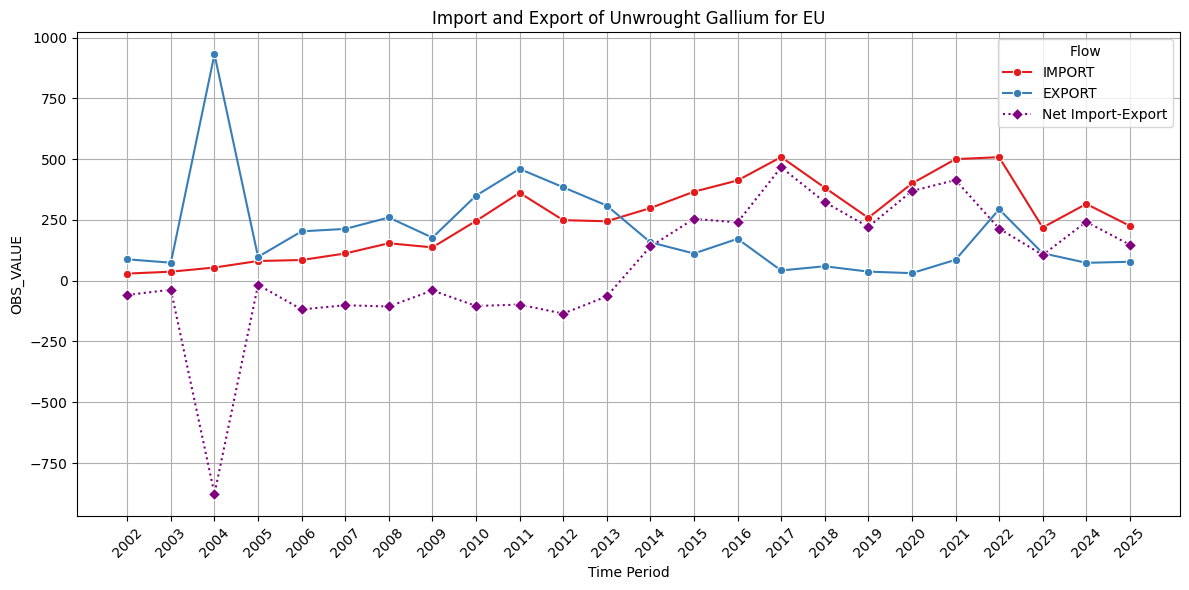

In [1]:
##### Initial import and setup #####
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
import plotly

# Ignore warnings for cleaner output
import warnings

warnings.filterwarnings("ignore", "Workbook contains no default style", UserWarning)

# Load data/EUROSTAT_COMEXT.csv into a DataFrame
comext_df = pd.read_csv("data/EUROSTAT_COMEXT.csv")

# Select relevant columns
selected_columns = [
    "reporter",
    "partner",
    "product",
    "PRODUCT",
    "flow",
    "FLOW",
    "indicators",
    "TIME_PERIOD",
    "OBS_VALUE",
]
eurostat_df = comext_df[selected_columns].copy()

# Plot product "81129289" and indicators "QUANTITY_IN_100KG" with "TIME_PERIOD" on x-axis and "OBS_VALUE" on y-axis, colored by "flow"
# Plot two seperate for partner = "EXT_EU27_2020" and partner = "INT_EU27_2020" => With different legends and colors and markers
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=eurostat_df[
        (eurostat_df["product"] == 81129289)
        & (eurostat_df["indicators"] == "QUANTITY_IN_100KG")
        & (eurostat_df["partner"] == "EXT_EU27_2020")
    ],
    x="TIME_PERIOD",
    y="OBS_VALUE",
    hue="FLOW",
    marker="o",
    linestyle="-",
    palette="Set1",
)
# sns.lineplot(data=eurostat_df[(eurostat_df["product"] == 81129289) & (eurostat_df["indicators"] == "QUANTITY_IN_100KG") & (eurostat_df["partner"] == "INT_EU27_2020")],
#              x="TIME_PERIOD", y="OBS_VALUE", hue="FLOW", marker="s", linestyle="--", palette="Set2")
# Calculate and Plot the difference between FLOW = "IMPORT" and FLOW = "EXPORT" for partner = "EXT_EU27_2020"
net_import_export = eurostat_df[
    (eurostat_df["product"] == 81129289)
    & (eurostat_df["indicators"] == "QUANTITY_IN_100KG")
    & (eurostat_df["partner"] == "EXT_EU27_2020")
].pivot(index="TIME_PERIOD", columns="FLOW", values="OBS_VALUE")
net_import_export["NET_IMPORT_EXPORT"] = (
    net_import_export["IMPORT"] - net_import_export["EXPORT"]
)
sns.lineplot(
    data=net_import_export,
    x=net_import_export.index,
    y="NET_IMPORT_EXPORT",
    marker="D",
    linestyle=":",
    color="purple",
    label="Net Import-Export",
)
plt.title("Import and Export of Unwrought Gallium for EU")
plt.xlabel("Time Period")
plt.ylabel("OBS_VALUE")
plt.legend(title="Flow")
plt.xticks(rotation=45, ticks=net_import_export.index)
plt.tight_layout()
plt.grid()
plt.show()